In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.graph_objs as go
import plotly.offline as pyo
import plotly.express as px

from wordcloud import WordCloud
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 'large',
    'axes.titlesize': 'x-large',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
    'axes.facecolor': 'black',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'figure.facecolor': 'black',
    'figure.edgecolor': 'black',
    'savefig.facecolor': 'black',
    'savefig.edgecolor': 'black',
    'text.color': 'white',
})

In [ ]:
df=pd.read_csv("/content/Online Retail.csv")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,15287.518434
std,218.081158,96.759853,1484.746041
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,14367.000000
50%,3.000000,2.080000,15287.000000
75%,10.000000,4.130000,16255.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df[df['UnitPrice']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,15287,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,15287,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,15287,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,15287,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,15287,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,15287,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,15287,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,15287,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,15287,United Kingdom


In [ ]:
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,15287,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,15287,United Kingdom


In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
df[df['UnitPrice']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,539392.000000,539392.000000,539392.000000
mean,9.845904,4.673648,15287.600185
std,215.412652,94.614722,1488.109389
min,-80995.000000,0.001000,12346.000000
25%,1.000000,1.250000,14359.000000
50%,3.000000,2.080000,15287.000000
75%,10.000000,4.130000,16265.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df['Transaction'] = df['Quantity'].apply(lambda x: 'Sold' if x < 0 else 'Bought')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Bought
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Bought
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought


In [ ]:
df['Transaction'].value_counts()

,count
Transaction,
Bought,530104
Sold,9288


In [ ]:
distribution = df['UnitPrice'].value_counts(normalize=True) * 100
print(distribution)

UnitPrice
1.25        9.361652
1.65        7.078525
0.85        5.283171
2.95        5.148019
0.42        4.548269
              ...   
2196.67     0.000185
17836.46    0.000185
11586.50    0.000185
888.06      0.000185
1.07        0.000185
Name: proportion, Length: 1628, dtype: float64


In [ ]:
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Bought
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Bought
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,Bought
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,Bought
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,Bought
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,Bought


In [ ]:
def missing_values_count(df):
    total_missing = df.isna().sum().sum()
    total_cells = df.size
    missing_percent = round((total_missing / total_cells) * 100, 2)
    print(f"Total Missing Values: {total_missing}")
    print(f"Percentage of Missing Values: {missing_percent}%\n")

    for col in df.columns:
        col_missing = df[col].isna().sum()
        col_cells = df[col].size
        col_missing_percent = round((col_missing / col_cells) * 100, 2)
        print(f"Column '{col}' Missing Values: {col_missing}")
        print(f"Percentage of Missing Values: {col_missing_percent}%\n")

In [ ]:
 missing_values_count(df)

Total Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'InvoiceNo' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'StockCode' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'Description' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'Quantity' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'InvoiceDate' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'UnitPrice' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'CustomerID' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'Country' Missing Values: 0
Percentage of Missing Values: 0.0%

Column 'Transaction' Missing Values: 0
Percentage of Missing Values: 0.0%



In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['StockCode'].nunique()

3938

In [ ]:
df['InvoiceNo'].nunique()

23796

In [ ]:
# sort the dataframe by Quantity in descending order
sorted_df = df.sort_values(by=['Quantity'], ascending=False)

# get the CustomerID with the highest Quantity
customer_id = sorted_df.iloc[0]['CustomerID']
highest_quantity = sorted_df.iloc[0]['Quantity']

print(f"CustomerID {customer_id} bought the highest quantity of {highest_quantity}.")

CustomerID 16446 bought the highest quantity of 80995.


In [ ]:
customer_totals = df.groupby('CustomerID')['Quantity'].sum()

# sort the customer_totals by Quantity in descending order
sorted_totals = customer_totals.sort_values(ascending=False)

# get the top 10 customer IDs
top_10_customers = sorted_totals.head(10)

print("Top 10 Customers by Quantity:")
print(top_10_customers)

Top 10 Customers by Quantity:
CustomerID
15287    418230
14646    196143
12415     76946
14911     76930
17450     69029
18102     64122
17511     63012
13694     61803
14298     58021
14156     57025
Name: Quantity, dtype: int64


In [ ]:
df['Quantity'].min()

-80995

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # Convert to datetime format

# Extract the date part from 'InvoiceDate' column
df['Date'] = df['InvoiceDate'].dt.date
# Create new column with hour, minute, and second components
df['Time'] = df['InvoiceDate'].dt.strftime('%H:%M:%S')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Bought,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Bought,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought,2010-12-01,08:26:00


In [ ]:
# Create new column with time interval labels
df['Time'] = df['InvoiceDate'].dt.hour
df['Time of Day'] = ['Early Morning' if x < 6 else ('Morning' if x < 12 else ('Noon' if x < 14 else ('Afternoon' if x < 18 else ('Evening' if x < 22 else 'Night')))) for x in df['Time']]

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction,Date,Time,Time of Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Bought,2010-12-01,8,Morning
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought,2010-12-01,8,Morning
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Bought,2010-12-01,8,Morning
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought,2010-12-01,8,Morning
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Bought,2010-12-01,8,Morning


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 539392 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    539392 non-null  object        
 1   StockCode    539392 non-null  object        
 2   Description  539392 non-null  object        
 3   Quantity     539392 non-null  int64         
 4   InvoiceDate  539392 non-null  datetime64[ns]
 5   UnitPrice    539392 non-null  float64       
 6   CustomerID   539392 non-null  int64         
 7   Country      539392 non-null  object        
 8   Transaction  539392 non-null  object        
 9   Date         539392 non-null  object        
 10  Time         539392 non-null  int32         
 11  Time of Day  539392 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(7)
memory usage: 51.4+ MB


/tmp/ipython-input-2924761645.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




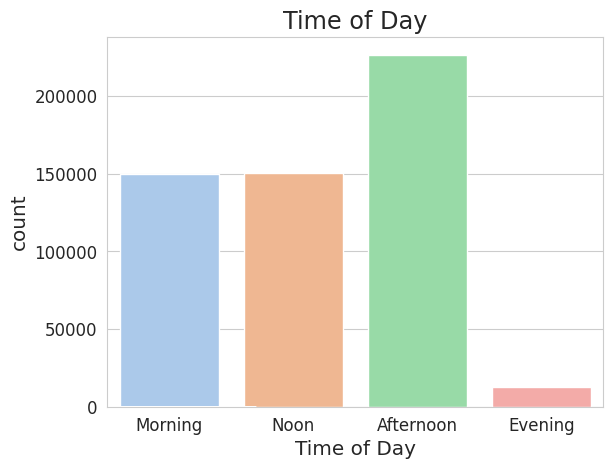

In [ ]:
sns.set_style("whitegrid")

# Create a countplot
sns.countplot(data=df, x='Time of Day', palette="pastel")

# Create a circle for the center of the pie chart
circle = plt.Circle((0, 0), 0.7, color='white')

# Add the circle to the plot
plt.gca().add_artist(circle)

# Add a title
plt.title("Time of Day")

# Display the plot
plt.show()


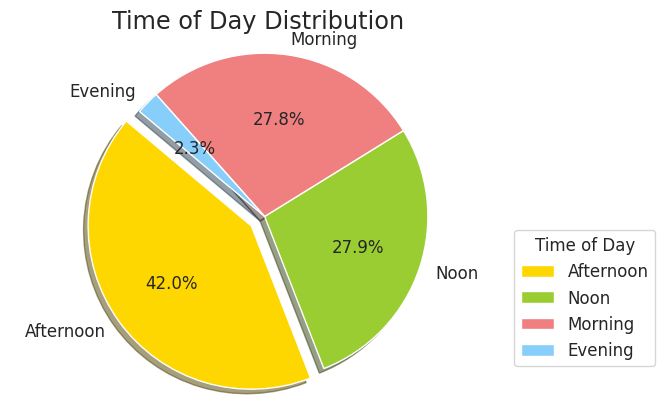

In [ ]:
counts = df['Time of Day'].value_counts()

# Data
labels = counts.index.tolist()
sizes = counts.tolist()
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0.1, 0, 0, 0)  # explode 1st slice

# Plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Time of Day Distribution')

plt.axis('equal')
plt.legend(title='Time of Day', loc='best', bbox_to_anchor=(1, 0.5))
plt.show()

In [ ]:
invoice_counts = df['InvoiceNo'].value_counts()

# Find the invoice number with the highest count
max_invoice_no = invoice_counts.idxmax()

# Filter the DataFrame to get the rows with the maximum invoice number
max_invoice_customer = df[df['InvoiceNo'] == max_invoice_no]

# Extract the customer ID with the maximum invoice number
max_customer_id = max_invoice_customer['CustomerID'].values[0]

print("Customer ID with Maximum Transactions:", max_customer_id)

Customer ID with Maximum Transactions: 15287
